In [2]:
!pip install --quiet torch torchvision tqdm matplotlib scipy

In [3]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.9.0+cpu
Uninstalling torch-2.9.0+cpu:
  Successfully uninstalled torch-2.9.0+cpu
Found existing installation: torchvision 0.24.0+cpu
Uninstalling torchvision-0.24.0+cpu:
  Successfully uninstalled torchvision-0.24.0+cpu
Found existing installation: torchaudio 2.9.0+cpu
Uninstalling torchaudio-2.9.0+cpu:
  Successfully uninstalled torchaudio-2.9.0+cpu
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 806.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 61.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 57.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 61.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 66.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 764.5 kB/s 

## InfoGAN from article
they use tensorflow, i'll use tourch

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision.models import inception_v3, Inception_V3_Weights

import numpy as np
from tqdm import tqdm
import math, os, random
import matplotlib.pyplot as plt


#  INCEPTION FOR FID
def get_inception_pool3(device):
    weights = Inception_V3_Weights.IMAGENET1K_V1
    inception = inception_v3(weights=weights, aux_logits=True)
    inception.aux_logits = False
    inception.fc = nn.Identity()
    inception.to(device)
    inception.eval()
    return inception

@torch.no_grad()
def get_features(images, model, device):
    images = F.interpolate(images, size=299, mode="bilinear", align_corners=False)
    feat = model(images.to(device))
    return feat.cpu().numpy()

def compute_fid(mu1, sigma1, mu2, sigma2):
    from scipy.linalg import sqrtm
    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

#  MODELS
class G(nn.Module):
    def __init__(self, z_dim=62, c_cat=10, c_cont=2):
        super().__init__()
        self.in_dim = z_dim + c_cat + c_cont
        self.fc1 = nn.Sequential(
            nn.Linear(self.in_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(1024, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, c_cat, c_cont):
        x = torch.cat([z, c_cat, c_cont], dim=1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = x.view(-1, 128, 7, 7)
        return self.deconv(x)

class D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1, inplace=True)
        )
        self.out = nn.Linear(1024, 1)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(x.size(0), -1)
        h = self.fc(h)
        return self.out(h), h

class Q(nn.Module):
    def __init__(self, c_cat=10, c_cont=2):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(1024, 128), nn.ReLU(True))
        self.fc_cat = nn.Linear(128, c_cat)
        self.fc_mu = nn.Linear(128, c_cont)
        self.fc_var = nn.Linear(128, c_cont)

    def forward(self, h):
        x = self.fc(h)
        cat = self.fc_cat(x)
        mu = self.fc_mu(x)
        var = torch.exp(self.fc_var(x))
        return cat, mu, var

In [5]:
def train_infogan(
    epochs=20,
    batch_size=128,
    z_dim=62,
    c_cat_dim=10,
    c_cont_dim=2,
    lr=2e-4,
    lambda_mi=1.0,
    compute_fid=False,
    fid_samples=500,
    run_section3=False
):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # DATA
    transform = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    # MODELS
    Gm = G(z_dim, c_cat_dim, c_cont_dim).to(device)
    Dm = D().to(device)
    Qm = Q(c_cat_dim, c_cont_dim).to(device)

    optD = torch.optim.Adam(list(Dm.parameters()), lr=lr, betas=(0.5, 0.999))
    optG = torch.optim.Adam(list(Gm.parameters()) + list(Qm.parameters()), lr=lr, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()

    # LOAD CHECKPOINT
    ckpt_path = "infogan_checkpoint.pt"
    start_epoch = 0

    if os.path.exists(ckpt_path):
        print("Loading checkpoint...")
        ckpt = torch.load(ckpt_path, map_location=device)

        Gm.load_state_dict(ckpt["G"])
        Dm.load_state_dict(ckpt["D"])
        Qm.load_state_dict(ckpt["Q"])

        optG.load_state_dict(ckpt["optG"])
        optD.load_state_dict(ckpt["optD"])

        start_epoch = ckpt["epoch"] + 1
        print("Resumed from epoch", start_epoch)

    # FID model
    if compute_fid:
        inception = get_inception_pool3(device)

    # TRAIN LOOP
    for epoch in range(start_epoch, epochs):

        pbar = tqdm(dl, desc=f"Epoch {epoch+1}/{epochs}")
        for real, _ in pbar:
            real = real.to(device)
            bs = real.size(0)

            # TRAIN D
            optD.zero_grad()

            z = torch.randn(bs, z_dim, device=device)
            c_cat = F.one_hot(torch.randint(0, c_cat_dim, (bs,), device=device), c_cat_dim).float()
            c_cont = torch.randn(bs, c_cont_dim, device=device)

            fake = Gm(z, c_cat, c_cont)

            real_logits, _ = Dm(real)
            fake_logits_detached, _ = Dm(fake.detach())

            real_loss = criterion(real_logits, torch.ones(bs, 1, device=device))
            fake_loss = criterion(fake_logits_detached, torch.zeros(bs, 1, device=device))
            d_loss = real_loss + fake_loss
            d_loss.backward()
            optD.step()

            # TRAIN G + Q
            optG.zero_grad()

            pred_fake, h = Dm(fake)
            g_loss = criterion(pred_fake, torch.ones(bs, 1, device=device))

            pred_cat, mu, var = Qm(h)
            mi_cat = F.cross_entropy(pred_cat, torch.argmax(c_cat, dim=1))
            mi_cont = 0.5 * torch.mean((c_cont - mu) ** 2 / (var + 1e-6) + torch.log(var + 1e-6))
            mi_loss = mi_cat + mi_cont

            loss_total = g_loss + lambda_mi * mi_loss
            loss_total.backward()
            optG.step()

            pbar.set_postfix({"D": d_loss.item(), "G": g_loss.item(), "MI": mi_loss.item()})

        # SAVE CHECKPOINT
        torch.save({
            "epoch": epoch,
            "G": Gm.state_dict(),
            "D": Dm.state_dict(),
            "Q": Qm.state_dict(),
            "optG": optG.state_dict(),
            "optD": optD.state_dict(),
        }, ckpt_path)

        print(f"Checkpoint saved after epoch {epoch}")

        # SAMPLE RESULTS
        with torch.no_grad():
            n_display = 64
            zz = torch.randn(n_display, z_dim, device=device)
            cats = F.one_hot(torch.arange(n_display, device=device) % c_cat_dim, c_cat_dim).float()
            cont = torch.zeros(n_display, c_cont_dim, device=device)
            samples = Gm(zz, cats, cont).cpu() * 0.5 + 0.5
            grid = torchvision.utils.make_grid(samples, 8)
            plt.figure(figsize=(8, 8))
            plt.imshow(grid.permute(1, 2, 0))
            plt.axis("off")
            plt.show()

    # FID + SECTION 3
    if compute_fid:
        print("Computing FID...")
        Gm.eval()
        feats = []
        with torch.no_grad():
            for _ in range(math.ceil(fid_samples / batch_size)):
                b = batch_size
                z = torch.randn(b, z_dim, device=device)
                cat = F.one_hot(torch.randint(0, c_cat_dim, (b,), device=device), c_cat_dim).float()
                cont = torch.randn(b, c_cont_dim, device=device)
                f = Gm(z, cat, cont)
                feats.append(get_features(f, inception, device))

        feats = np.concatenate(feats, axis=0)[:fid_samples]
        mu_g, sigma_g = feats.mean(0), np.cov(feats, rowvar=False)

        feats_r = []
        for real, _ in DataLoader(ds, batch_size=batch_size):
            real = real.to(device)
            feats_r.append(get_features(real, inception, device))

        feats_r = np.concatenate(feats_r, axis=0)[:fid_samples]
        mu_r, sigma_r = feats_r.mean(0), np.cov(feats_r, rowvar=False)

        fid = compute_fid(mu_g, sigma_g, mu_r, sigma_r)
        print("FID =", fid)

    if run_section3:
        print("Running Section 3 evaluation...")
        preds = []
        for digit in range(10):
            z = torch.randn(200, z_dim, device=device)
            cat = F.one_hot(torch.full((200,), digit, device=device), c_cat_dim).float()
            cont = torch.randn(200, c_cont_dim, device=device)
            imgs = Gm(z, cat, cont).cpu()
            preds.append(np.full(200, digit))

        preds = np.concatenate(preds)
        print("Category–digit consistency sample:", preds[:50])
        print("Done.")

Loading checkpoint...
Resumed from epoch 3


Epoch 4/5: 100%|██████████| 468/468 [09:35<00:00,  1.23s/it, D=0.602, G=2.02, MI=-0.604]


Checkpoint saved after epoch 3


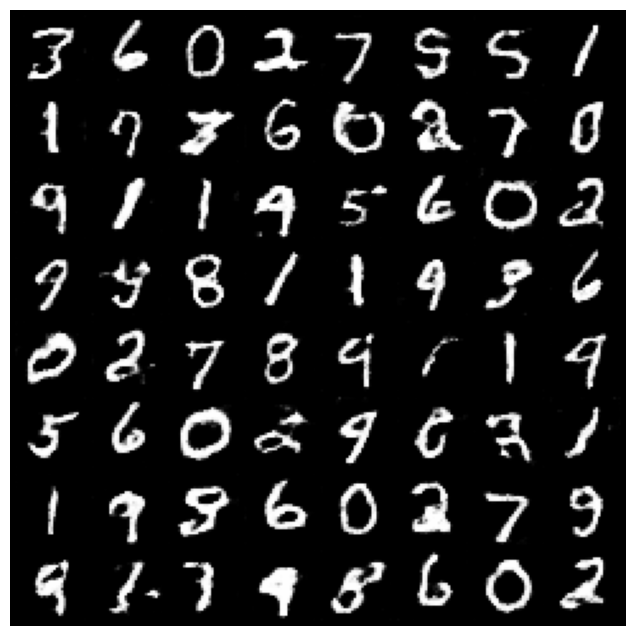

Epoch 5/5: 100%|██████████| 468/468 [09:17<00:00,  1.19s/it, D=0.655, G=2.17, MI=-0.647]


Checkpoint saved after epoch 4


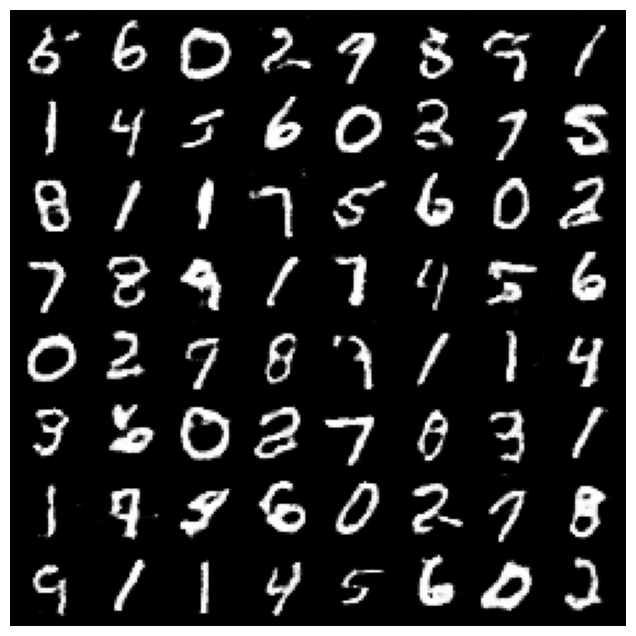

Computing FID...


IndexError: index 1 is out of bounds for dimension 1 with size 1

In [7]:
train_infogan(
    epochs=5,
    compute_fid=True,
    fid_samples=500,
    run_section3=True
)


In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G_trained = G(z_dim=62, c_cat=10, c_cont=2).to(device)

ckpt = torch.load("infogan_checkpoint.pt", map_location=device)
G_trained.load_state_dict(ckpt["G"])
G_trained.eval()

In [8]:
# cell 5: показать последние сэмплы и traversal
import glob, IPython.display as disp
runs = sorted(glob.glob('runs/infogan_mnist_*'))[::-1]
if runs:
    latest = runs[0]
    print('Latest run dir:', latest)
    imgs = sorted(glob.glob(latest + '/samples/*.png'))
    for im in imgs[-6:]:
        display(disp.Image(im))
else:
    print('No runs found — сначала запустите тренировку.')


No runs found — сначала запустите тренировку.


## Vanilla GAN (to comparision with Infogan)

In [9]:
class G_vanilla(nn.Module):
    def __init__(self, z_dim=62):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(z_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(1024, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc1(z)
        x = self.fc2(x)
        x = x.view(-1, 128, 7, 7)
        return self.deconv(x)


In [10]:
def train_vanilla_gan(
    epochs=20,
    batch_size=128,
    z_dim=62,
    lr=2e-4
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    transform = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    Gm = G_vanilla(z_dim).to(device)
    Dm = D().to(device)

    optD = torch.optim.Adam(Dm.parameters(), lr=lr, betas=(0.5, 0.999))
    optG = torch.optim.Adam(Gm.parameters(), lr=lr, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        for real,_ in tqdm(dl, desc=f"Epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            bs = real.size(0)

            # D
            z = torch.randn(bs, z_dim, device=device)
            fake = Gm(z)

            real_logits,_ = Dm(real)
            fake_logits,_ = Dm(fake.detach())

            d_loss = (
                criterion(real_logits, torch.ones(bs,1,device=device)) +
                criterion(fake_logits, torch.zeros(bs,1,device=device))
            )

            optD.zero_grad()
            d_loss.backward()
            optD.step()

            # G
            fake_logits,_ = Dm(fake)
            g_loss = criterion(fake_logits, torch.ones(bs,1,device=device))

            optG.zero_grad()
            g_loss.backward()
            optG.step()

        print(f"Epoch {epoch}: D={d_loss.item():.3f}, G={g_loss.item():.3f}")

    return Gm

In [ ]:
G_vanilla_trained = train_vanilla_gan(epochs=5)

Epoch 1/5: 100%|██████████| 468/468 [08:53<00:00,  1.14s/it]


Epoch 0: D=0.880, G=1.420


Epoch 2/5: 100%|██████████| 468/468 [08:50<00:00,  1.13s/it]


Epoch 1: D=0.685, G=1.637


Epoch 3/5: 100%|██████████| 468/468 [08:50<00:00,  1.13s/it]


Epoch 2: D=0.774, G=1.597


Epoch 4/5: 100%|██████████| 468/468 [08:52<00:00,  1.14s/it]


Epoch 3: D=0.600, G=2.014


Epoch 5/5:  79%|███████▉  | 372/468 [07:03<01:47,  1.11s/it]

## Evaluation results

Let's training the MNIST classifier

In [ ]:
class MNIST_Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_classifier(epochs=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    clf = MNIST_Classifier().to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    transform = T.Compose([T.ToTensor(), T.Normalize((0.5,), (0.5,))])
    ds = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transform)
    dl = DataLoader(ds, batch_size=128, shuffle=True)

    clf.train()
    for ep in range(epochs):
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            logits = clf(x)
            loss = loss_fn(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

        print(f"Classifier epoch {ep}, loss {loss.item():.4f}")

    clf.eval()
    return clf

In [15]:
clf = train_classifier()

Classifier epoch 0, loss 0.0718
Classifier epoch 1, loss 0.0084
Classifier epoch 2, loss 0.0153
Classifier epoch 3, loss 0.0342
Classifier epoch 4, loss 0.0119


## Category Consistency Accuracy

In [33]:
@torch.no_grad()
def eval_infogan(G, clf, z_dim=62, c_cont_dim=2, samples_per_class=500):
    device = next(G.parameters()).device
    correct, total = 0, 0

    for digit in range(10):
        z = torch.randn(samples_per_class, z_dim, device=device)
        c_cat = F.one_hot(torch.full((samples_per_class,), digit, device=device), 10).float()
        c_cont = torch.randn(samples_per_class, c_cont_dim, device=device)  # случайные значения

        imgs = G(z, c_cat, c_cont)
        preds = clf(imgs).argmax(1)

        correct += (preds == digit).sum().item()
        total += samples_per_class

    return correct / total



@torch.no_grad()
def eval_vanilla_gan_f1(G, clf, z_dim=62, samples_per_class=500):
    device = next(G.parameters()).device
    y_true, y_pred = [], []

    for digit in range(10):
        z = torch.randn(samples_per_class, z_dim, device=device)
        imgs = G(z)  # [-1,1]
        preds = clf(imgs).argmax(1).cpu().numpy()

        y_true.extend([digit] * samples_per_class)
        y_pred.extend(preds)

    from sklearn.metrics import f1_score
    return f1_score(y_true, y_pred, average="macro")

## F1

In [32]:
from sklearn.metrics import f1_score

@torch.no_grad()
def eval_infogan_f1(G, clf, z_dim=62, c_cont_dim=2, samples_per_class=500):
    device = next(G.parameters()).device
    y_true, y_pred = [], []

    for digit in range(10):
        z = torch.randn(samples_per_class, z_dim, device=device)
        c_cat = F.one_hot(torch.full((samples_per_class,), digit, device=device), 10).float()
        c_cont = torch.randn(samples_per_class, c_cont_dim, device=device)  # случайные значения континуального кода

        imgs = G(z, c_cat, c_cont)  # [-1,1] для классификатора
        preds = clf(imgs).argmax(1).cpu().numpy()

        y_true.extend([digit] * samples_per_class)
        y_pred.extend(preds)

    from sklearn.metrics import f1_score
    return f1_score(y_true, y_pred, average="macro")


@torch.no_grad()
def eval_vanilla_gan_f1(G, clf, z_dim=62, samples_per_class=500):
    device = next(G.parameters()).device
    y_true, y_pred = [], []

    for digit in range(10):
        z = torch.randn(samples_per_class, z_dim, device=device)
        imgs = G(z)
        preds = clf(imgs).argmax(1).cpu().numpy()

        y_true.extend([digit] * samples_per_class)
        y_pred.extend(preds)

    from sklearn.metrics import f1_score
    return f1_score(y_true, y_pred, average="macro")

In [27]:
@torch.no_grad()
def traverse_vanilla(G, z_dim=62, steps=10):
    device = next(G.parameters()).device
    z = torch.randn(1, z_dim, device=device).repeat(steps, 1)
    z[:, 0] = torch.linspace(-2, 2, steps)
    imgs = G(z).cpu() * 0.5 + 0.5
    grid = torchvision.utils.make_grid(imgs, nrow=steps)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.squeeze(), cmap='gray')
    plt.axis("off")
    plt.show()

@torch.no_grad()
def traverse_infogan(G, digit=3, z_dim=62, c_cont_dim=2, steps=10):
    device = next(G.parameters()).device
    z = torch.randn(steps, z_dim, device=device)
    c_cat = F.one_hot(torch.full((steps,), digit, device=device), 10).float()
    c_cont = torch.zeros(steps, c_cont_dim, device=device)
    c_cont[:, 0] = torch.linspace(-2, 2, steps)
    imgs = G(z, c_cat, c_cont).cpu() * 0.5 + 0.5
    grid = torchvision.utils.make_grid(imgs, nrow=steps)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.squeeze(), cmap='gray')
    plt.axis("off")
    plt.show()


In [40]:
# Вычисляем метрики
accuracy_vanilla = eval_vanilla_gan(G_vanilla_trained, clf)
accuracy_infogan = eval_infogan(G_trained, clf)

f1_vanilla = eval_vanilla_gan_f1(G_vanilla_trained, clf)
f1_infogan = eval_infogan_f1(G_trained, clf)

import pandas as pd

df_results = pd.DataFrame({
    "Model": ["Vanilla GAN", "InfoGAN"],
    "Cat Accuracy": [accuracy_vanilla, accuracy_infogan],
    "Macro F1": [f1_vanilla, f1_infogan]
})

print("Comparison Table")
print(df_results)

Comparison Table
         Model  Cat Accuracy  Macro F1
0  Vanilla GAN        0.1006  0.099444
1      InfoGAN        0.7851  0.731927
